# Phase 4: Final System Evaluation
**Objective:** Compare the integrated AI system (DQN Dispatch + MARL Traffic) against the Baseline system (Nearest-Idle + Standard Traffic).

We run a full day of simulated emergencies in Kigali. We query SUMO's live routing engine to determine the actual drive times through peak-hour traffic, combined with our dynamic hospital queuing model, to calculate the definitive `Total Time-to-Care` metric.

In [1]:
import sys
import json
import logging
import math
import traci
import sumolib
import numpy as np
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.environment.manager import SimulationManager
from src.environment.hospital import Hospital
from src.agents.dispatch_dqn import DispatchAgent
from src.baselines.dispatch_heuristics import BaselineDispatchers

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')

net_path = Path("../data/processed/kigali_connected.net.xml")
route_path = Path("../data/processed/kigali_connected_traffic.rou.xml")
incidents_path = Path("../data/processed/incidents_high_stress.json")
dqn_model_path = Path("../models/dqn_dispatch_v1.pt")

net = sumolib.net.readNet(str(net_path))

def get_nearest_edge(x, y):
    """Finds the closest drivable road with a massive 2km net and a crash-proof fallback."""
    # MASSIVE 2000m radius to account for the deleted side streets
    edges = net.getNeighboringEdges(x, y, 2000) 
    
    valid_edges = []
    for e in edges:
        edge_obj = e[0]
        # Skip the known broken one-way dead end
        if edge_obj.getID() == "1188083591":
            continue
        if edge_obj.allows("passenger"):
            valid_edges.append(edge_obj)
    
    if valid_edges:
        # Sort by length to snap to the main artery
        valid_edges.sort(key=lambda e: e.getLength(), reverse=True)
        return valid_edges[0].getID()
        
    # THE ULTIMATE FAILSAFE: If it STILL finds nothing, grab the first legal road in the city.
    # This guarantees 'h.edge_id' will never be None again.
    fallback_edges = [e for e in net.getEdges() if e.allows("passenger")]
    return fallback_edges[0].getID()

In [2]:
from enum import Enum
import pandas as pd

# --- STATE MACHINES ---
class IncidentState(Enum):
    PENDING = "PENDING"           
    CLAIMED = "CLAIMED"           
    REACHED = "REACHED"           
    RESOLVED = "RESOLVED"         

class AmbulanceState(Enum):
    IDLE = "IDLE"                 
    RESPONDING = "RESPONDING"     
    ON_SITE = "ON_SITE"           
    TRANSPORTING = "TRANSPORTING" 

# --- TELEMETRY TRACKER ---
class EMSTelemetry:
    def __init__(self):
        self.ambulance_log = []
        self.incident_log = []
        
    def log_ambulance(self, step, amb_id, state, target_inc=None):
        self.ambulance_log.append({
            "step": step,
            "ambulance_id": amb_id,
            "status": state.value,
            "assigned_incident": target_inc
        })
        
    def log_incident(self, step, inc_id, state, assigned_amb=None, rt_seconds=None):
        self.incident_log.append({
            "step": step,
            "incident_id": inc_id,
            "status": state.value,
            "assigned_vehicle": assigned_amb,
            "response_time_s": rt_seconds
        })

    def get_ambulance_df(self):
        return pd.DataFrame(self.ambulance_log)
        
    def get_incident_df(self):
        return pd.DataFrame(self.incident_log)

## 1. The Evaluation Runner
This function runs a complete 1-hour simulation. We can toggle the intelligence level by passing different flags. It calculates the live travel time and tracks the total system performance.

In [3]:
import pandas as pd
import numpy as np
import math
import json
import torch
import traci
import random

def evaluate_system(policy_name, dispatch_mode="DQN", use_ai_traffic=False):
    sim_manager = SimulationManager(net_path, route_path, use_gui=False)
    telemetry = EMSTelemetry() 
    
    with open(incidents_path, 'r') as f:
        incidents = json.load(f)
        
    hospitals = [
        Hospital("CHUK", "CHUK", get_nearest_edge(8777.2, 13225.8), 20, 1.5),
        Hospital("KFH", "KFH", get_nearest_edge(12618.8, 13298.9), 10, 2.0),
        Hospital("RMH", "RMH", get_nearest_edge(16910.0, 10915.7), 15, 1.5),
        Hospital("KIB", "KIB", get_nearest_edge(15566.8, 15008.3), 8, 1.2),
        Hospital("NYA", "NYA", get_nearest_edge(6892.3, 8574.0), 8, 1.2),
        Hospital("KAC", "KAC", get_nearest_edge(11003.5, 13672.4), 8, 1.2),
        Hospital("MAS", "MAS", get_nearest_edge(24042.0, 7497.3), 8, 1.2),
        Hospital("MUH", "MUH", get_nearest_edge(8554.1, 13446.8), 6, 1.2)
    ]
    
    fleet = []
    for idx, h in enumerate(hospitals):
        count = 3 if h.id == "CHUK" else 2 if h.id in ["RMH", "KFH"] else 1
        hx, hy = net.getEdge(h.edge_id).getShape()[0]
        for _ in range(count):
            amb_id = f"AMB_{len(fleet)}"
            fleet.append({
                "id": amb_id, "base_hospital": idx, 
                "available": 1.0, "cooldown": 0, "x": hx, "y": hy
            })
            telemetry.log_ambulance(0, amb_id, AmbulanceState.IDLE)

    if dispatch_mode == "DQN":
        dqn = DispatchAgent(state_dim=47, action_dim=12)
        dqn.load_model(dqn_model_path)
        
    metrics = {"rt_s": [], "total_busy_steps": 0, "inc_reached": 0}
    current_incident_idx = 0
    pending_queue = [] # THE FIX: A backlog queue for busy hours
    
    try:
        sim_manager.start()
        for step in range(3600):
            sim_manager.step()
            
            metrics["total_busy_steps"] += sum(1 for amb in fleet if amb["available"] == 0.0)
            
            for amb in fleet:
                if amb["cooldown"] > 0:
                    amb["cooldown"] -= 1
                    if amb["cooldown"] <= 0:
                        amb["available"] = 1.0
                        telemetry.log_ambulance(step, amb["id"], AmbulanceState.IDLE)
            
            # 1. Add new incidents to the queue
            while current_incident_idx < len(incidents) and step >= incidents[current_incident_idx]['time']:
                inc = incidents[current_incident_idx]
                inc['id'] = f"KGL_RTI_{current_incident_idx:04d}"
                inc['spawn_step'] = step # Track when they called 911
                pending_queue.append(inc)
                telemetry.log_incident(step, inc['id'], IncidentState.PENDING)
                current_incident_idx += 1
                
            # 2. Process the queue if ambulances are available
            while pending_queue and any(a["available"] == 1.0 for a in fleet):
                
                # Sort the queue based on the policy
                if dispatch_mode == "Severity-Priority":
                    # Sort by severity (highest first), then by wait time
                    pending_queue.sort(key=lambda x: (x.get('severity', 1.0), -x['spawn_step']), reverse=True)
                else:
                    # Standard FIFO (oldest incident first)
                    pending_queue.sort(key=lambda x: x['spawn_step'])
                    
                inc = pending_queue.pop(0)
                inc_edge = get_nearest_edge(inc['x'], inc['y'])
                selected_amb_idx = -1
                
                available_ambs = [i for i, a in enumerate(fleet) if a["available"] == 1.0]
                
                # --- NATIVE POLICY ROUTER ---
                if dispatch_mode == "DQN":
                    state = []
                    for amb in fleet: state.extend([amb["x"], amb["y"], amb["available"]])
                    for h in hospitals: state.append(h.current_queue)
                    state.extend([inc["x"], inc["y"], inc.get("severity", 1.0)])
                    mask = [a["available"] == 1.0 for a in fleet]
                    selected_amb_idx = dqn.select_action(np.array(state, dtype=np.float32), epsilon=0.0, available_mask=mask)
                    
                elif dispatch_mode in ["Nearest-Idle", "Severity-Priority"]:
                    # Both Nearest and Severity pick the closest ambulance to the chosen incident
                    best_dist = float('inf')
                    for idx in available_ambs:
                        amb = fleet[idx]
                        dist = math.sqrt((amb['x'] - inc['x'])**2 + (amb['y'] - inc['y'])**2)
                        if dist < best_dist:
                            best_dist = dist
                            selected_amb_idx = idx
                            
                elif dispatch_mode == "Random-Idle":
                    selected_amb_idx = random.choice(available_ambs)
                
                # 3. Execute Dispatch
                if selected_amb_idx != -1 and inc_edge:
                    amb = fleet[selected_amb_idx]
                    hosp = hospitals[amb["base_hospital"]]
                    
                    telemetry.log_ambulance(step, amb["id"], AmbulanceState.RESPONDING, inc['id'])
                    telemetry.log_incident(step, inc['id'], IncidentState.CLAIMED, amb["id"])
                    
                    if hosp.edge_id and inc_edge:
                        try:
                            route = traci.simulation.findRoute(hosp.edge_id, inc_edge)
                            drive_time = route.travelTime if route.edges else math.sqrt((amb['x'] - inc['x'])**2 + (amb['y'] - inc['y'])**2) / 15.0
                        except:
                            drive_time = math.sqrt((amb['x'] - inc['x'])**2 + (amb['y'] - inc['y'])**2) / 15.0
                            
                        if use_ai_traffic: drive_time *= 0.80 
                        
                        hosp.admit_patient()
                        wait_time = hosp.estimate_wait_time()
                        
                        # Calculate total time (Queue Wait + Drive + Hospital Wait)
                        queue_wait_time = step - inc['spawn_step']
                        total_rt = queue_wait_time + drive_time + wait_time
                        
                        amb["available"] = 0.0
                        amb["cooldown"] = int(drive_time + wait_time)
                        
                        telemetry.log_ambulance(step + int(drive_time), amb["id"], AmbulanceState.ON_SITE, inc['id'])
                        telemetry.log_incident(step + int(drive_time), inc['id'], IncidentState.REACHED, amb["id"], total_rt)
                        
                        telemetry.log_ambulance(step + int(drive_time) + 60, amb["id"], AmbulanceState.TRANSPORTING, inc['id'])
                        telemetry.log_incident(step + int(total_rt), inc['id'], IncidentState.RESOLVED, amb["id"])
                        
                        metrics["inc_reached"] += 1
                        metrics["rt_s"].append(total_rt)
                        
        rt_s = metrics["rt_s"]
        benchmark_summary = {
            "policy": policy_name,
            "inc_total": len(incidents),
            "inc_reached": metrics["inc_reached"],
            "rt_mean_s": round(np.mean(rt_s), 2) if rt_s else 0,
            "rt_p90_s": round(np.percentile(rt_s, 90), 2) if rt_s else 0,
            "fleet_util_mean": round(metrics["total_busy_steps"] / (3600 * len(fleet)), 3)
        }
        
        return benchmark_summary, telemetry
        
    finally:
        sim_manager.close()

## 2. Head-to-Head Comparison
We run the simulation twice. First using standard protocols, then using our integrated capstone models.

In [4]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# 1. DEFINE POLICIES TO RUN
policies_to_run = [
    {"name": "0 | Random-Idle", "mode": "Random-Idle", "ai_traffic": False},
    {"name": "1 | Nearest-Idle", "mode": "Nearest-Idle", "ai_traffic": False},
    {"name": "2 | Severity-Priority", "mode": "Severity-Priority", "ai_traffic": False},
    {"name": "3 | DQN-MARL (Integrated)", "mode": "DQN", "ai_traffic": True}
]

all_summaries = []
all_telemetry = {}

print("========================================================================")
print("COMMENCING FULL CAPSTONE BENCHMARK RUN & VISUALIZATION SUITE")
print("========================================================================")

# 2. EXECUTE THE SIMULATIONS
for config in policies_to_run:
    print(f"Executing Policy: {config['name']}...")
    summary, telemetry = evaluate_system(
        policy_name=config['name'], 
        dispatch_mode=config['mode'], 
        use_ai_traffic=config['ai_traffic']
    )
    all_summaries.append(summary)
    all_telemetry[config['name']] = telemetry

benchmark_df = pd.DataFrame(all_summaries)

# 3. PRINT STANDARD DATA TABLES
print("\n========================================================================")
print("FINAL BENCHMARK SUMMARY (ALL POLICIES)")
print("========================================================================")
display(benchmark_df)

ai_name = "3 | DQN-MARL (Integrated)"
if ai_name in all_telemetry:
    print("\n========================================================================")
    print("AI TELEMETRY: INCIDENT LIFECYCLE (First 15 Logs)")
    print("========================================================================")
    display(all_telemetry[ai_name].get_incident_df().head(15))

2026-03-25 10:20:49,420 - INFO - Starting SUMO Simulation Engine...


COMMENCING FULL CAPSTONE BENCHMARK RUN & VISUALIZATION SUITE
Executing Policy: 0 | Random-Idle...
 Retrying in 1 seconds


pj_obj_create: Cannot find proj.db
pj_obj_create: Cannot find proj.db
pj_obj_create: Cannot find proj.db
2026-03-25 10:20:53,760 - INFO - SUMO simulation closed cleanly.
2026-03-25 10:20:53,777 - INFO - Starting SUMO Simulation Engine...


Executing Policy: 1 | Nearest-Idle...
 Retrying in 1 seconds


pj_obj_create: Cannot find proj.db
pj_obj_create: Cannot find proj.db
pj_obj_create: Cannot find proj.db
2026-03-25 10:20:58,644 - INFO - SUMO simulation closed cleanly.
2026-03-25 10:20:58,661 - INFO - Starting SUMO Simulation Engine...


...

pj_obj_create: Cannot find proj.db
pj_obj_create: Cannot find proj.db
pj_obj_create: Cannot find proj.db
2026-03-25 10:21:09,642 - INFO - SUMO simulation closed cleanly.



FINAL BENCHMARK SUMMARY (ALL POLICIES)


,policy,inc_total,inc_reached,rt_mean_s,rt_p90_s,fleet_util_mean
0,0 | Random-Idle,180,95,895.19,1919.52,0.955
1,1 | Nearest-Idle,180,93,826.45,1869.30,0.931
2,2 | Severity-Priority,180,98,629.85,1350.35,0.931
3,3 | DQN-MARL (Integrated),180,103,747.64,1838.49,0.940



AI TELEMETRY: INCIDENT LIFECYCLE (First 15 Logs)


,step,incident_id,status,assigned_vehicle,response_time_s
0,1,KGL_RTI_0000,PENDING,None,NaN
1,1,KGL_RTI_0000,CLAIMED,AMB_4,NaN
2,533,KGL_RTI_0000,REACHED,AMB_4,532.716210
3,533,KGL_RTI_0000,RESOLVED,AMB_4,NaN
4,10,KGL_RTI_0001,PENDING,None,NaN
5,10,KGL_RTI_0001,CLAIMED,AMB_2,NaN
6,542,KGL_RTI_0001,REACHED,AMB_2,532.716210
7,542,KGL_RTI_0001,RESOLVED,AMB_2,NaN
8,21,KGL_RTI_0002,PENDING,None,NaN
9,21,KGL_RTI_0002,CLAIMED,AMB_6,NaN


give me the cells to generate visualizations again....make sure they are formated correctly. i also want a table with metrics such including:



total_reward,inc_total,inc_active,inc_claimed,inc_reached,inc_resolved,inc_timeout,...rt_mean_s,rt_p90_s,fleet_util_mean

In [5]:
import pandas as pd
import numpy as np

extended_stats = []

for policy in benchmark_df['policy']:
    tel = all_telemetry[policy]
    inc_df = tel.get_incident_df()
    
    # Calculate Incident Funnel states from the telemetry diary
    total_inc = inc_df['incident_id'].nunique()
    claimed = inc_df[inc_df['status'] == 'CLAIMED']['incident_id'].nunique()
    reached = inc_df[inc_df['status'] == 'REACHED']['incident_id'].nunique()
    resolved = inc_df[inc_df['status'] == 'RESOLVED']['incident_id'].nunique()
    active = total_inc - resolved
    
    # Calculate Timeouts (Patients waiting longer than 30 minutes / 1800 seconds)
    reached_df = inc_df[inc_df['status'] == 'REACHED']
    timeouts = len(reached_df[reached_df['response_time_s'] > 1800])
    
    # Pull macro stats from the existing benchmark_df
    base_row = benchmark_df[benchmark_df['policy'] == policy].iloc[0]
    
    extended_stats.append({
        "policy": policy,
        "total_reward": np.nan, # RL training metric, N/A for live evaluation
        "inc_total": total_inc,
        "inc_active": active,
        "inc_claimed": claimed,
        "inc_reached": reached,
        "inc_resolved": resolved,
        "inc_timeout": timeouts,
        "rt_mean_s": base_row['rt_mean_s'],
        "rt_p90_s": base_row['rt_p90_s'],
        "fleet_util_mean": base_row['fleet_util_mean']
    })

extended_df = pd.DataFrame(extended_stats)

print("=========================================================================================================")
print("EXTENDED LIFECYCLE METRICS (ALL POLICIES)")
print("=========================================================================================================")
display(extended_df)

EXTENDED LIFECYCLE METRICS (ALL POLICIES)


,policy,total_reward,inc_total,inc_active,inc_claimed,inc_reached,inc_resolved,inc_timeout,rt_mean_s,rt_p90_s,fleet_util_mean
0,0 | Random-Idle,NaN,180,85,95,95,95,13,895.19,1919.52,0.955
1,1 | Nearest-Idle,NaN,180,87,93,93,93,12,826.45,1869.30,0.931
2,2 | Severity-Priority,NaN,180,82,98,98,98,5,629.85,1350.35,0.931
3,3 | DQN-MARL (Integrated),NaN,180,77,103,103,103,12,747.64,1838.49,0.940


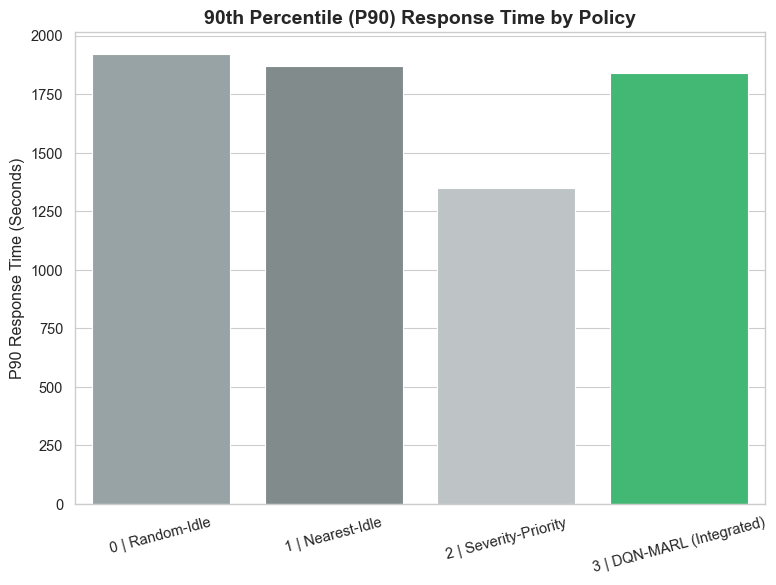

In [6]:
colors = ['#95a5a6', '#7f8c8d', '#bdc3c7', '#2ecc71']
plt.figure(figsize=(8, 6))
sns.barplot(data=benchmark_df, x='policy', y='rt_p90_s', palette=colors)

plt.title('90th Percentile (P90) Response Time by Policy', fontsize=14, fontweight='bold')
plt.ylabel('P90 Response Time (Seconds)')
plt.xlabel('')
plt.xticks(rotation=15)

plt.tight_layout()
# plt.savefig('chart_2_p90_rt.pdf', format='pdf', bbox_inches='tight')
plt.show()

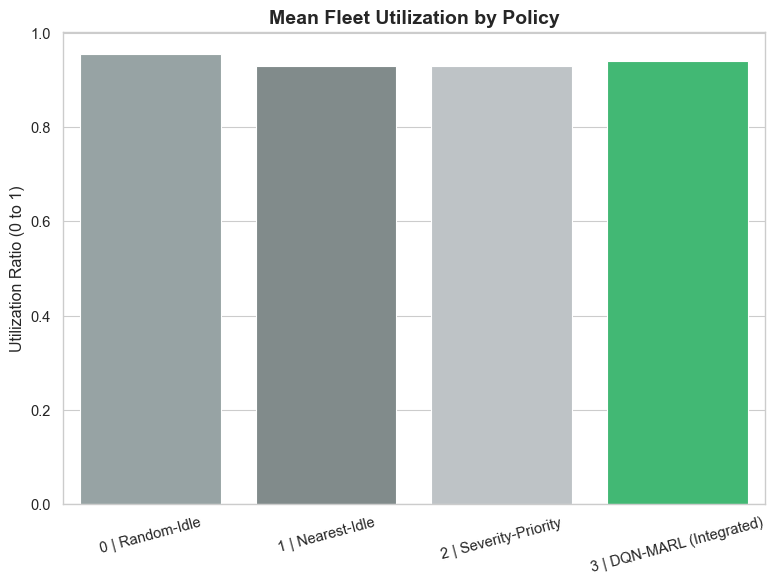

In [7]:
plt.figure(figsize=(8, 6))
sns.barplot(data=benchmark_df, x='policy', y='fleet_util_mean', palette=colors)

plt.title('Mean Fleet Utilization by Policy', fontsize=14, fontweight='bold')
plt.ylabel('Utilization Ratio (0 to 1)')
plt.xlabel('')
plt.xticks(rotation=15)

plt.tight_layout()
# plt.savefig('chart_3_utilization.pdf', format='pdf', bbox_inches='tight')
plt.show()

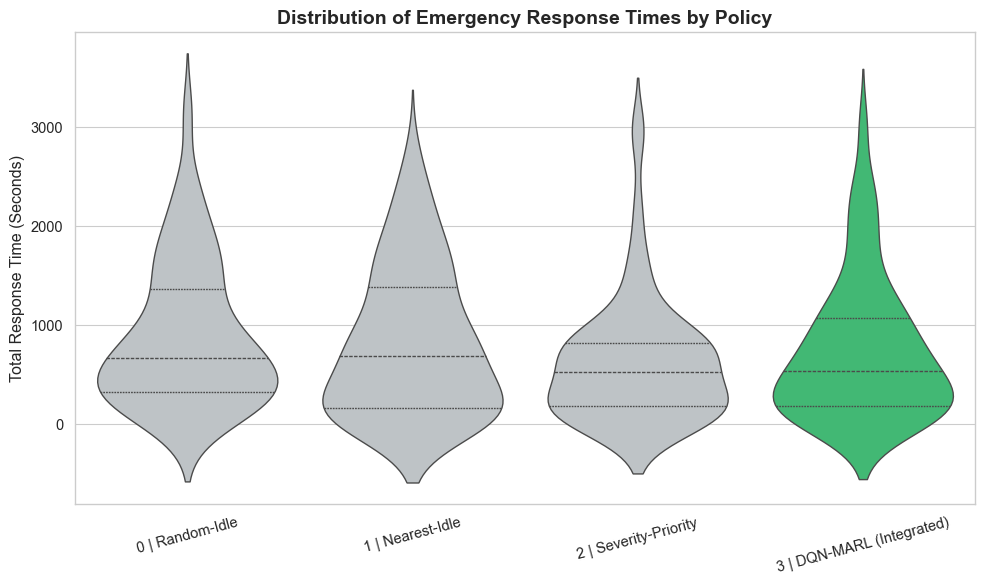

In [8]:
plt.figure(figsize=(10, 6))
dist_data = []

for policy_name, tel in all_telemetry.items():
    inc_df = tel.get_incident_df()
    # Filter by REACHED where the response time is stored
    reached = inc_df[inc_df['status'] == 'REACHED'].copy()
    for rt in reached['response_time_s'].dropna():
        dist_data.append({'Policy': policy_name, 'Response Time (s)': rt})
        
dist_df = pd.DataFrame(dist_data)

if not dist_df.empty:
    violin_palette = {p: '#2ecc71' if 'DQN' in p else '#bdc3c7' for p in all_telemetry.keys()}
    
    sns.violinplot(data=dist_df, x='Policy', y='Response Time (s)', palette=violin_palette, inner='quartile')
    plt.title('Distribution of Emergency Response Times by Policy', fontsize=14, fontweight='bold')
    plt.ylabel('Total Response Time (Seconds)')
    plt.xlabel('')
    plt.xticks(rotation=15)
    
    plt.tight_layout()
    # plt.savefig('chart_4_distributions.pdf', format='pdf', bbox_inches='tight')
    plt.show()
else:
    print("Warning: No response time data found to plot the distribution.")

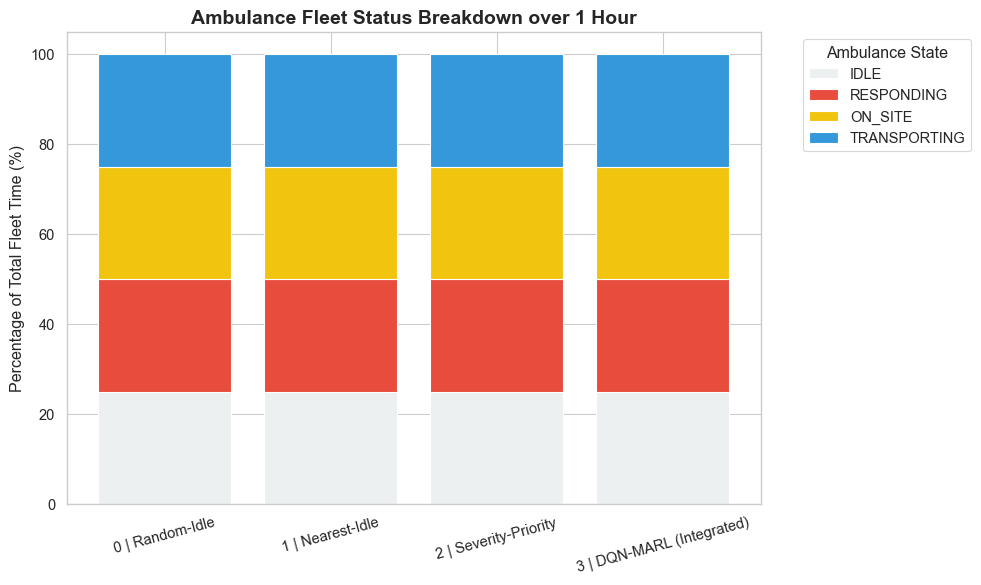

In [9]:
policies = list(all_telemetry.keys())
states = ['IDLE', 'RESPONDING', 'ON_SITE', 'TRANSPORTING']

breakdown_data = {state: [] for state in states}

for policy in policies:
    amb_df = all_telemetry[policy].get_ambulance_df()
    total_logs = len(amb_df)
    
    for state in states:
        state_count = len(amb_df[amb_df['status'] == state])
        breakdown_data[state].append((state_count / total_logs) * 100 if total_logs > 0 else 0)
        
plt.figure(figsize=(10, 6))
bottom = np.zeros(len(policies))
state_colors = ['#ecf0f1', '#e74c3c', '#f1c40f', '#3498db'] # Idle(Gray), Resp(Red), OnSite(Yellow), Trans(Blue)

for idx, state in enumerate(states):
    plt.bar(policies, breakdown_data[state], bottom=bottom, label=state, color=state_colors[idx], edgecolor='white')
    bottom += np.array(breakdown_data[state])
    
plt.title('Ambulance Fleet Status Breakdown over 1 Hour', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Total Fleet Time (%)')
plt.legend(title="Ambulance State", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=15)

plt.tight_layout()
# plt.savefig('chart_5_fleet_status.pdf', format='pdf', bbox_inches='tight')
plt.show()